# **IMAGE-ENHANCEMENT METHOD BASIC**

# NAMA : SERLY ELDINA
# NIM  : 26/589324/PPA/07352
# ADVANCED COMPUTER VISION

*   Under Exposure
*   Over Exposure
*   Blurred Image
*   Oversharpened Image
*   Noisy Image
*   Low Contrast
*   High Contrast
*   Low Resolution







# ***`1. IMAGE ENHANCEMENT PADA CITRA GELAP/UNDER EXPOSURE`***

Under-exposed Image:


Saving dark image.jpg to dark image (6).jpg
PSNR Input: 5.42 dB | HE: 7.58 dB | IN: 6.28 dB | Log: 10.31 dB


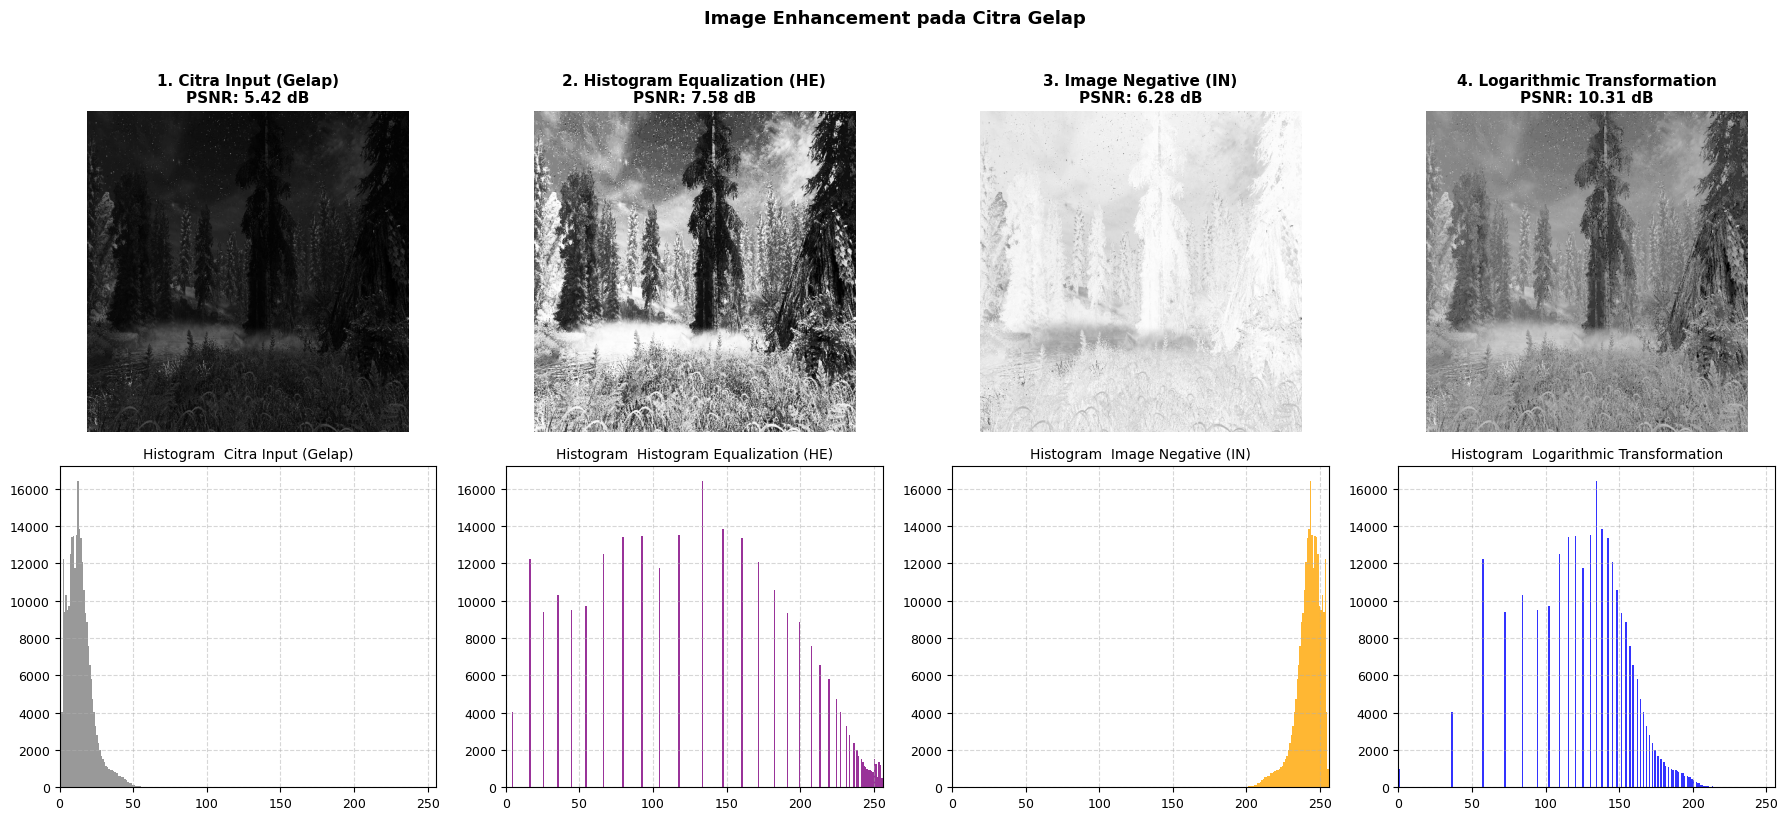

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Under-exposed Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_dark = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
if img_dark is None:
    img_dark = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2GRAY)
img_dark = cv2.resize(img_dark, (512, 512))

if 'img_original' not in locals():
    img_original = img_dark.copy()

# 1. Histogram Equalization (HE)
img_he = cv2.equalizeHist(img_dark)

# 2. Image Negative (IN)
img_in = 255 - img_dark

# 3. Logarithmic Transformation
c_param = 255 / np.log(1 + np.max(img_dark))
img_log = np.clip(c_param * np.log(1 + img_dark.astype(np.float32)), 0, 255).astype(np.uint8)

psnr_orig = calculate_psnr(img_original, img_dark)
psnr_he = calculate_psnr(img_original, img_he)
psnr_in = calculate_psnr(img_original, img_in)
psnr_log = calculate_psnr(img_original, img_log)

print(f"PSNR Input: {psnr_orig:.2f} dB | HE: {psnr_he:.2f} dB | IN: {psnr_in:.2f} dB | Log: {psnr_log:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_dark, img_he, img_in, img_log]
titles = [
    "1. Citra Input (Gelap)",
    "2. Histogram Equalization (HE)",
    "3. Image Negative (IN)",
    "4. Logarithmic Transformation"
]
colors = ['gray', 'purple', 'orange', 'blue']
psnr_vals = [psnr_orig, psnr_he, psnr_in, psnr_log]

for i in range(4):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].hist(images[i].ravel(), bins=256, range=[0, 256], color=colors[i], alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1]}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Image Enhancement pada Citra Gelap", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR, diperoleh:

1. Citra Input: PSNR 5,42 dB. Citra sangat gelap sehingga detail pada area gelap kurang terlihat.

2. Histogram Equalization (HE): PSNR 7,58 dB. Citra menjadi lebih terang dan kontras, tetapi beberapa bagian terlihat terlalu kontras atau menimbulkan noise.

3. Image Negative (IN): PSNR 6,28 dB. Nilai piksel dibalik sehingga citra menjadi terlalu terang dan detail kurang jelas.

4. Logarithmic Transformation: PSNR 10,31 dB. Hasil terbaik karena memiliki PSNR tertinggi dan membuat area gelap lebih terang sehingga detail objek lebih terlihat.

Kesimpulan: Logarithmic Transformation memberikan hasil paling baik berdasarkan nilai PSNR dan tampilan visual.


# ***`2. IMAGE ENHANCEMENT PADA CITRA TERANG/OVER EXPROSURE`***

Bright Image:


Saving bright_imge.jpg to bright_imge (1).jpg
PSNR Input: 8.73 dB | HE: 9.46 dB | IN: 7.30 dB | Gamma: 10.38 dB


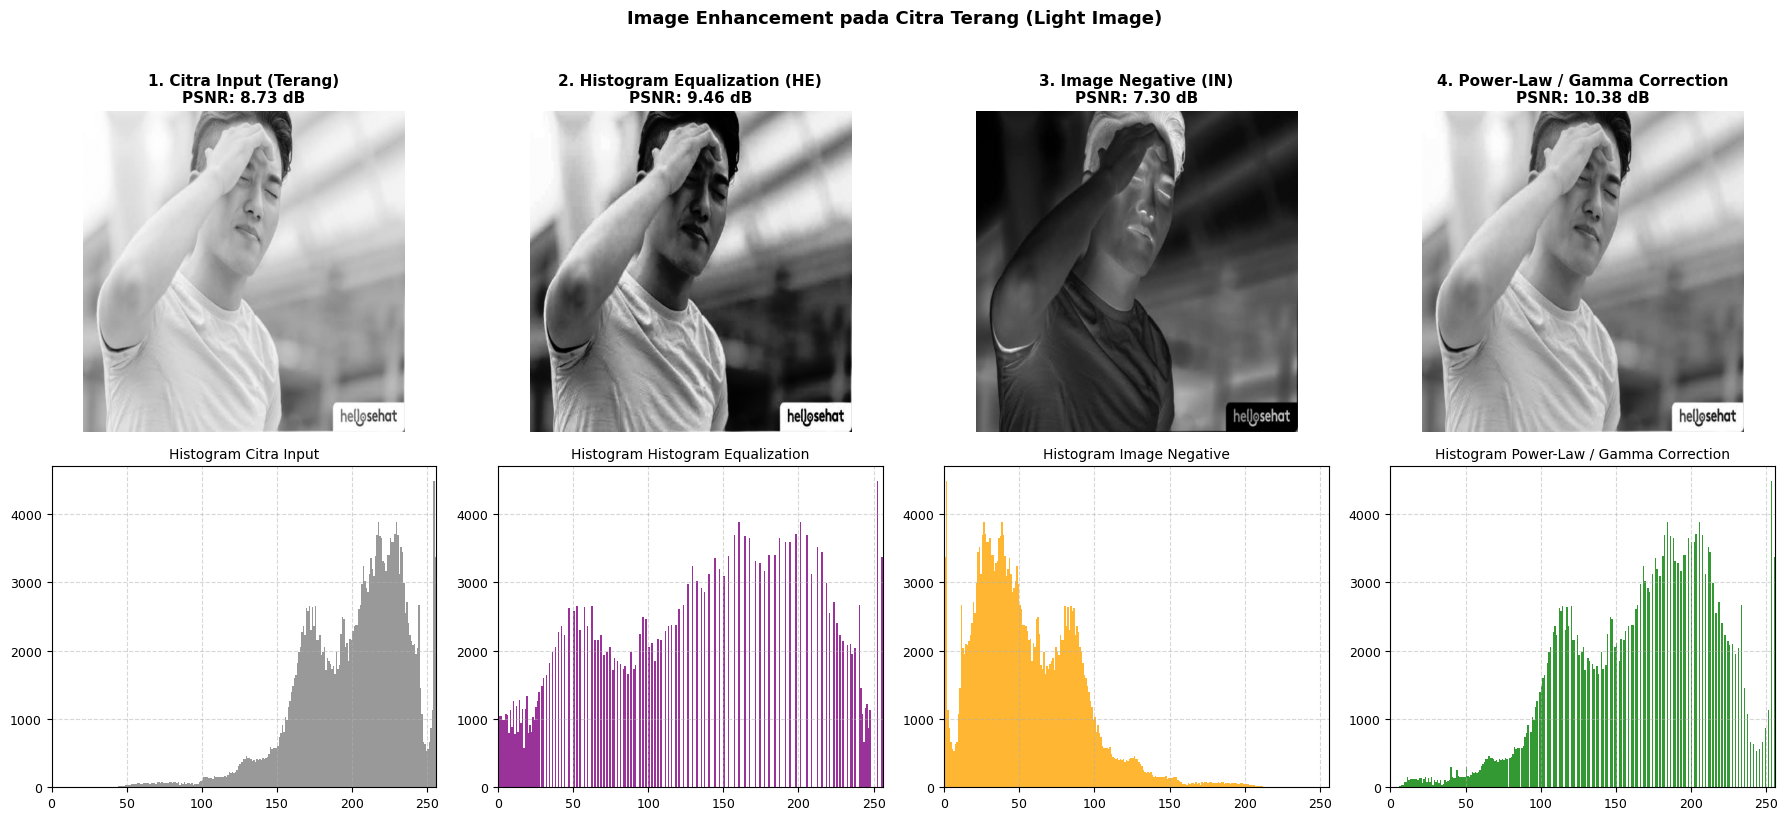

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Bright Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_light = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
if img_light is None:
    img_light = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2GRAY)
img_light = cv2.resize(img_light, (512, 512))

if 'img_original' not in locals():
    img_original = img_light.copy()

# 1. Histogram Equalization (HE)
img_he = cv2.equalizeHist(img_light)

# 2. Image Negative (IN)
img_in = 255 - img_light

# 3. Gamma Correction / Power-Law
gamma = 2.0
img_gamma = np.array(255 * (img_light / 255) ** gamma, dtype=np.uint8)

psnr_orig = calculate_psnr(img_original, img_light)
psnr_he = calculate_psnr(img_original, img_he)
psnr_in = calculate_psnr(img_original, img_in)
psnr_gamma = calculate_psnr(img_original, img_gamma)

print(f"PSNR Input: {psnr_orig:.2f} dB | HE: {psnr_he:.2f} dB | IN: {psnr_in:.2f} dB | Gamma: {psnr_gamma:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_light, img_he, img_in, img_gamma]
titles = [
    "1. Citra Input (Terang)",
    "2. Histogram Equalization (HE)",
    "3. Image Negative (IN)",
    "4. Power-Law / Gamma Correction"
]
colors = ['gray', 'purple', 'orange', 'green']
psnr_vals = [psnr_orig, psnr_he, psnr_in, psnr_gamma]

for i in range(4):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].hist(images[i].ravel(), bins=256, range=[0, 256], color=colors[i], alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Image Enhancement pada Citra Terang (Light Image)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra Over Exposure:

1. Citra Input: PSNR 8,73 dB. Citra terlalu terang sehingga sebagian besar piksel berada pada intensitas tinggi.

2. Histogram Equalization (HE): PSNR 9,46 dB. Distribusi intensitas menjadi lebih merata, tetapi beberapa bagian terlihat terlalu kontras.

3. Image Negative (IN): PSNR 7,30 dB. Citra menjadi terlalu gelap sehingga detail objek kurang terlihat.

4. Power-Law/Gamma Correction: PSNR 10,38 dB. Hasil terbaik karena memiliki PSNR tertinggi dan menghasilkan kecerahan yang lebih seimbang serta detail yang lebih jelas.

Kesimpulan: Power-Law/Gamma Correction memberikan hasil paling baik berdasarkan nilai PSNR dan tampilan visual.


# ***`3. IMAGE ENHANCEMENT PADA CITRA BURAM/BLUR`***

Blur Image:


Saving blur_image_sunflo.png to blur_image_sunflo (1).png
PSNR Input: 42.34 dB | Sharpen: 34.12 dB | Laplacian: 34.12 dB | DoG: 13.29 dB


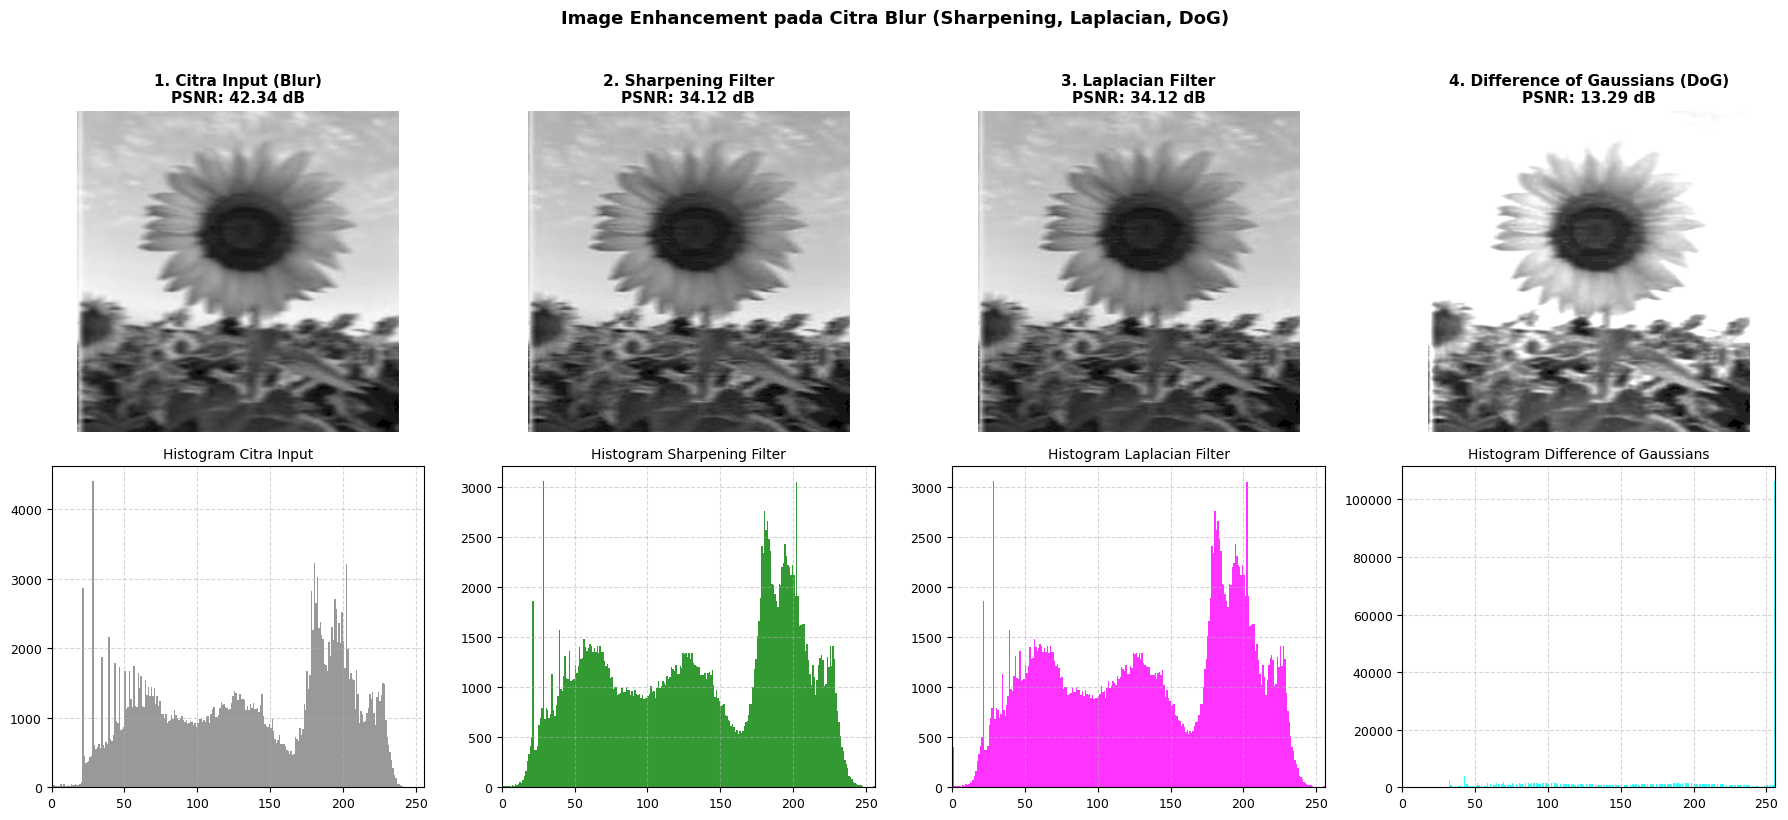

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Blur Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_blur = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
if img_blur is None:
    img_blur = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2GRAY)
img_blur = cv2.resize(img_blur, (512, 512))
img_original = cv2.GaussianBlur(img_blur, (5, 5), 2.0)

# 1. Sharpening Filter
kernel_sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
img_sharpen = cv2.filter2D(img_blur, -1, kernel_sharp)

# 2. Laplacian Filter
kernel_lap = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
lap = cv2.filter2D(img_blur.astype(np.float32), -1, kernel_lap)
img_laplacian = np.clip(img_blur.astype(np.float32) - lap, 0, 255).astype(np.uint8)

# 3. Difference of Gaussians (DoG)
g1 = cv2.GaussianBlur(img_blur, (0, 0), sigmaX=1.0)
g2 = cv2.GaussianBlur(img_blur, (0, 0), sigmaX=3.0)
dog = cv2.subtract(g1, g2)
img_dog = cv2.addWeighted(img_blur, 1.5, dog, 1.5, 0)
img_dog = np.clip(img_dog, 0, 255).astype(np.uint8)

psnr_orig = calculate_psnr(img_original, img_blur)
psnr_sharp = calculate_psnr(img_original, img_sharpen)
psnr_lap = calculate_psnr(img_original, img_laplacian)
psnr_dog = calculate_psnr(img_original, img_dog)

print(f"PSNR Input: {psnr_orig:.2f} dB | Sharpen: {psnr_sharp:.2f} dB | Laplacian: {psnr_lap:.2f} dB | DoG: {psnr_dog:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_blur, img_sharpen, img_laplacian, img_dog]
titles = [
    "1. Citra Input (Blur)",
    "2. Sharpening Filter",
    "3. Laplacian Filter",
    "4. Difference of Gaussians (DoG)"
]
colors = ['gray', 'green', 'magenta', 'cyan']
psnr_vals = [psnr_orig, psnr_sharp, psnr_lap, psnr_dog]

for i in range(4):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].hist(images[i].ravel(), bins=256, range=[0, 256], color=colors[i], alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Image Enhancement pada Citra Blur (Sharpening, Laplacian, DoG)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra Blur:

1. Citra Input: PSNR 42,34 dB. Citra masih mengalami blur dan digunakan sebagai kondisi awal.

2. Sharpening Filter: PSNR 34,12 dB. Tepi dan detail objek menjadi lebih tajam sehingga bagian bunga lebih jelas.

3. Laplacian Filter: PSNR 34,12 dB. Filter memperjelas tepi objek dan menghasilkan hasil yang mirip dengan sharpening filter.

4. Difference of Gaussians (DoG): PSNR 13,29 dB. Tepi objek terlihat lebih kuat, tetapi hasilnya lebih banyak distorsi dan noise.

Kesimpulan: Sharpening Filter dan Laplacian Filter memberikan hasil visual yang lebih baik dibandingkan DoG, sedangkan DoG memiliki PSNR paling rendah.


# ***`4. IMAGE ENHANCEMENT PADA CITRA TERLALU TAJAM`***

Oversharpened Image:


Saving ketajaman_image.jpg to ketajaman_image (4).jpg
PSNR Input: 7.46 dB | Mean: 8.71 dB | Gaussian: 8.84 dB | Median: 7.95 dB


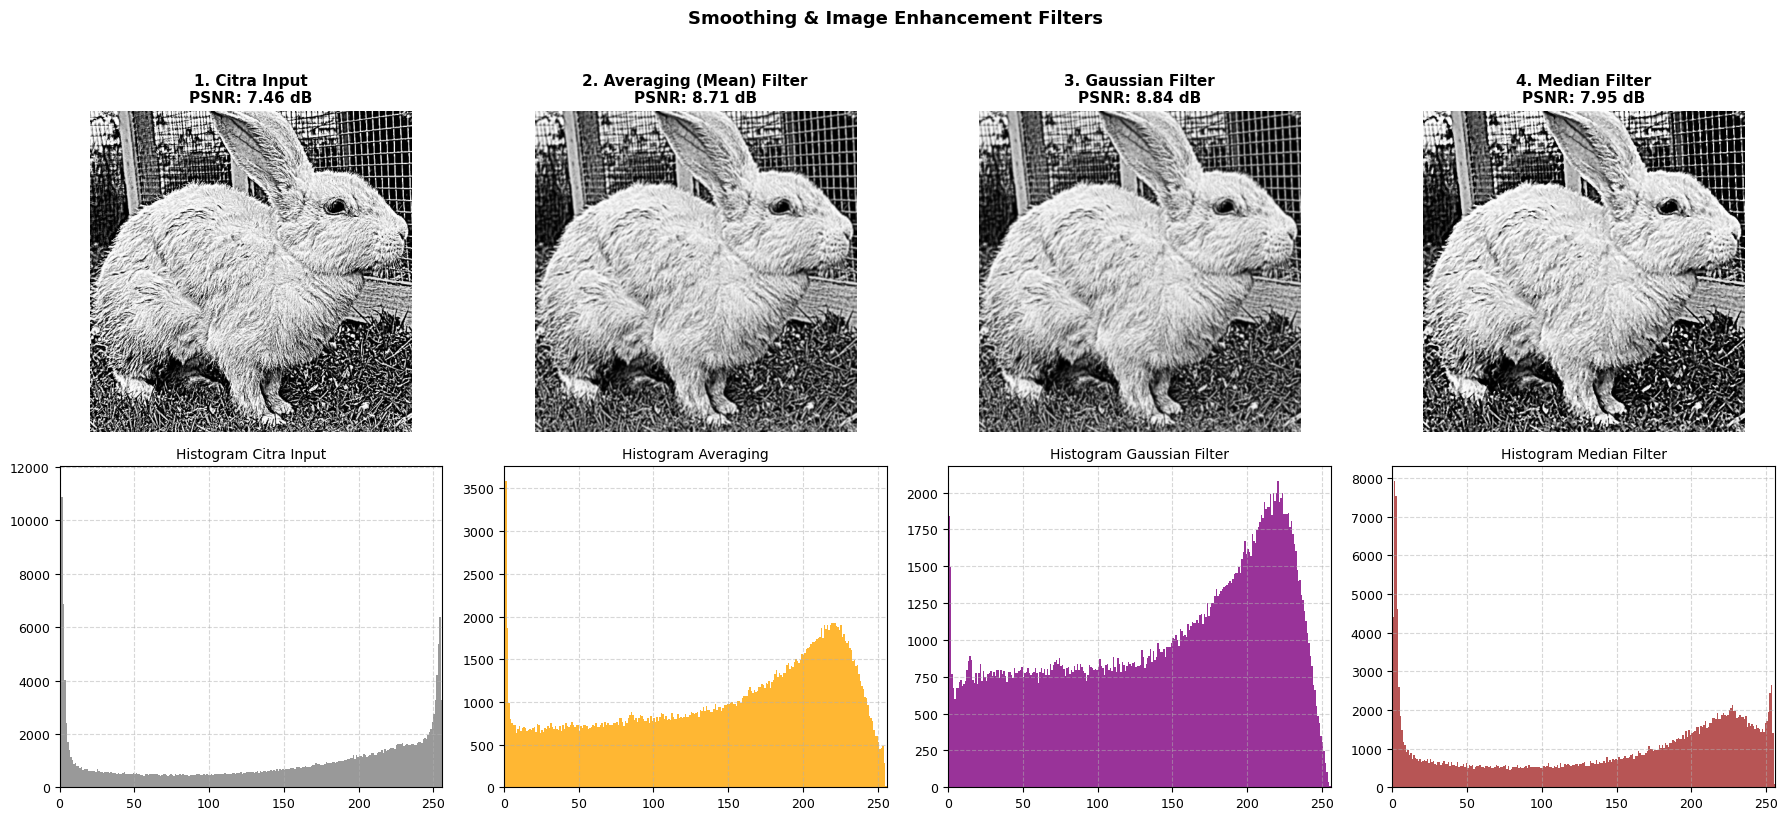

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Oversharpened Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_input = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
if img_input is None:
    img_input = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2GRAY)
img_input = cv2.resize(img_input, (512, 512))

if 'img_original' not in locals():
    img_original = img_input.copy()

# 1. Averaging (Mean) Filter Smoothing linear
kernel_mean = np.ones((3, 3), np.float32) / 9.0
img_mean = cv2.filter2D(img_input, -1, kernel_mean)

# 2. Gaussian Filter
img_gaussian = cv2.GaussianBlur(img_input, (5, 5), sigmaX=1.0)

# 3. Median Filter
img_median = cv2.medianBlur(img_input, 3)

psnr_orig = calculate_psnr(img_original, img_input)
psnr_mean = calculate_psnr(img_original, img_mean)
psnr_gauss = calculate_psnr(img_original, img_gaussian)
psnr_median = calculate_psnr(img_original, img_median)

print(f"PSNR Input: {psnr_orig:.2f} dB | Mean: {psnr_mean:.2f} dB | Gaussian: {psnr_gauss:.2f} dB | Median: {psnr_median:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_input, img_mean, img_gaussian, img_median]
titles = [
    "1. Citra Input",
    "2. Averaging (Mean) Filter",
    "3. Gaussian Filter",
    "4. Median Filter"
]
colors = ['gray', 'orange', 'purple', 'brown']
psnr_vals = [psnr_orig, psnr_mean, psnr_gauss, psnr_median]

for i in range(4):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].hist(images[i].ravel(), bins=256, range=[0, 256], color=colors[i], alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Smoothing & Image Enhancement Filters", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra Terlalu Tajam:

1. Citra Input: PSNR 7,46 dB. Citra memiliki noise dan tekstur yang cukup kasar.

2. Averaging (Mean) Filter: PSNR 8,71 dB. Noise berkurang dan citra menjadi lebih halus, tetapi tepi objek sedikit blur.

3. Gaussian Filter: PSNR 8,84 dB. Hasil terbaik karena memiliki PSNR tertinggi. Noise berkurang dan detail bulu kelinci masih cukup terjaga.

4. Median Filter: PSNR 7,95 dB. Dapat mengurangi noise, tetapi hasilnya masih terlihat memiliki tekstur atau butiran pada beberapa bagian.

Kesimpulan: Gaussian Filter memberikan hasil paling baik karena menghasilkan PSNR tertinggi serta mampu mengurangi noise tanpa terlalu menghilangkan detail.


# ***`5. IMAGE ENHANCEMENT PADA CITRA NOISE/DERAU`***

Noisy Image:


Saving noise_image.jpg to noise_image (2).jpg
PSNR Input: 8.86 dB | Averaging: 9.32 dB | Gaussian: 9.35 dB | Median: 9.08 dB


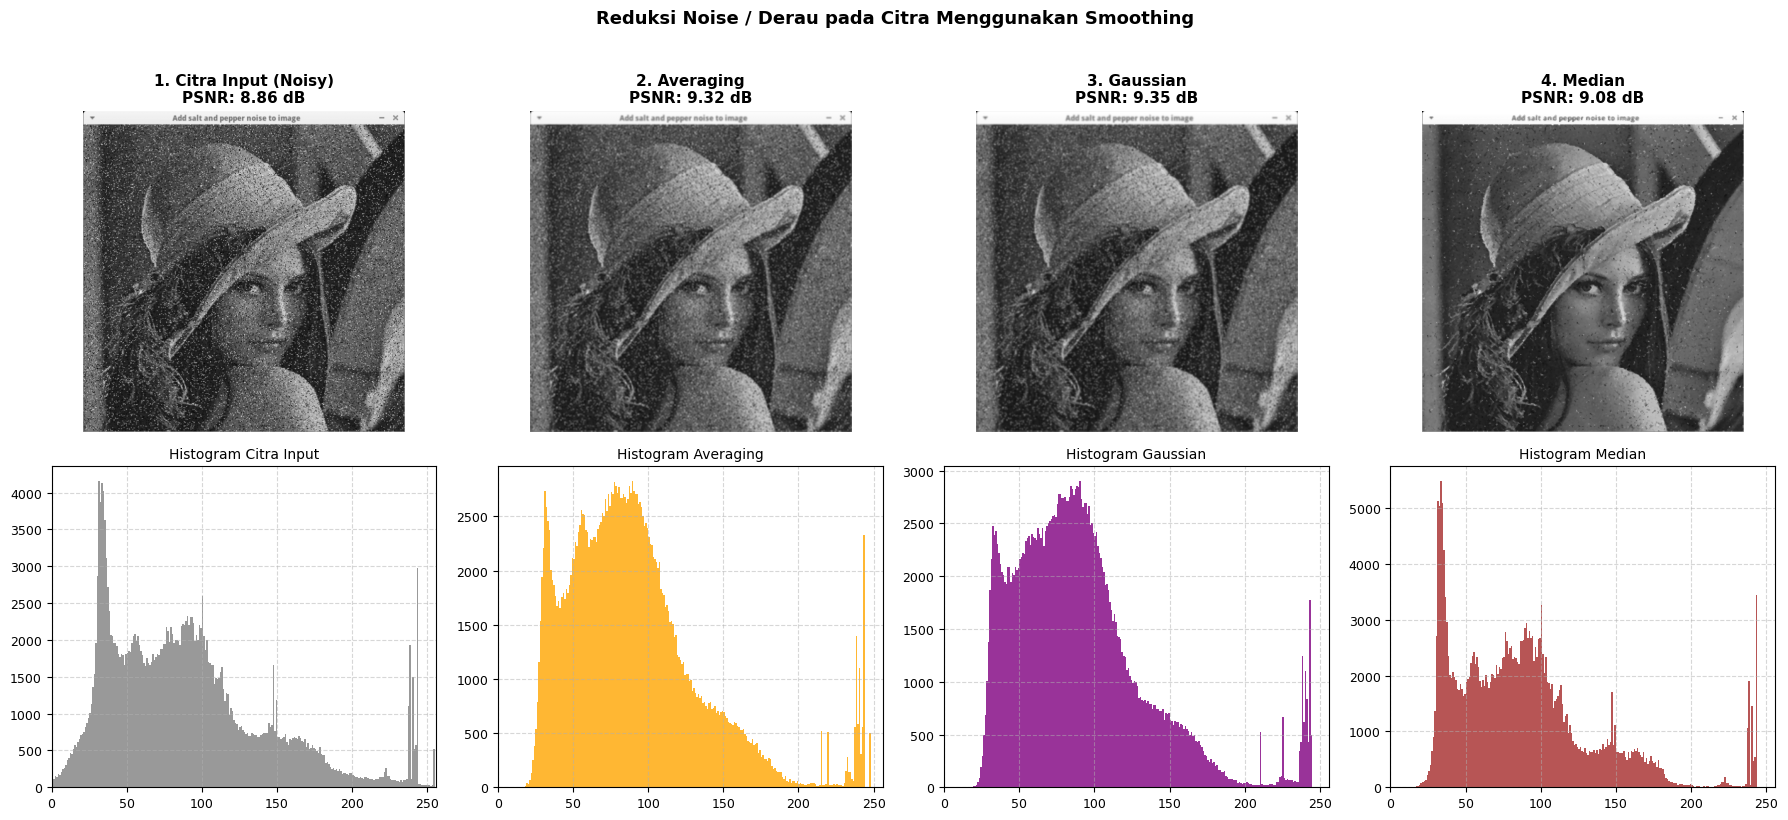

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Noisy Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_noisy = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
if img_noisy is None:
    img_noisy = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2GRAY)
img_noisy = cv2.resize(img_noisy, (512, 512))

if 'img_original' not in locals():
    img_original = img_noisy.copy()

# 1. Averaging (Mean): Smoothing linear
kernel_avg = np.ones((3, 3), np.float32) / 9.0
img_avg = cv2.filter2D(img_noisy, -1, kernel_avg)

# 2. Gaussian
img_gaussian = cv2.GaussianBlur(img_noisy, (5, 5), sigmaX=1.0)

# 3. Median
img_median = cv2.medianBlur(img_noisy, 3)

psnr_orig = calculate_psnr(img_original, img_noisy)
psnr_avg = calculate_psnr(img_original, img_avg)
psnr_gaussian = calculate_psnr(img_original, img_gaussian)
psnr_median = calculate_psnr(img_original, img_median)

print(f"PSNR Input: {psnr_orig:.2f} dB | Averaging: {psnr_avg:.2f} dB | Gaussian: {psnr_gaussian:.2f} dB | Median: {psnr_median:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_noisy, img_avg, img_gaussian, img_median]
titles = [
    "1. Citra Input (Noisy)",
    "2. Averaging",
    "3. Gaussian",
    "4. Median"
]
colors = ['gray', 'orange', 'purple', 'brown']
psnr_vals = [psnr_orig, psnr_avg, psnr_gaussian, psnr_median]

for i in range(4):
    axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].hist(images[i].ravel(), bins=256, range=[0, 256], color=colors[i], alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Reduksi Noise / Derau pada Citra Menggunakan Smoothing", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra Noise:

1. Citra Input: PSNR 8,86 dB. Citra memiliki noise yang cukup terlihat sehingga kualitas gambar menurun.

2. Averaging: PSNR 9,32 dB. Noise berkurang dan citra terlihat lebih bersih, tetapi tepi objek sedikit blur.

3. Gaussian Filter: PSNR 9,35 dB. Hasil terbaik karena memiliki PSNR tertinggi dan mampu mengurangi noise dengan tetap menjaga detail citra.

4. Median Filter: PSNR 9,08 dB. Noise cukup berkurang dan citra menjadi lebih halus, tetapi terdapat sedikit perubahan pada bagian tepi.

Kesimpulan: Gaussian Filter memberikan hasil paling baik karena memiliki nilai PSNR tertinggi, yaitu 9,35 dB.

# ***`6. IMAGE ENHANCEMENT PADA CITRA LOW CONTRAST`***

Low-Contrast Image:


Saving low_image.png to low_image (2).png
PSNR Input: 12.51 dB | CS: 8.61 dB | HE: 9.38 dB | MinMax: 8.03 dB


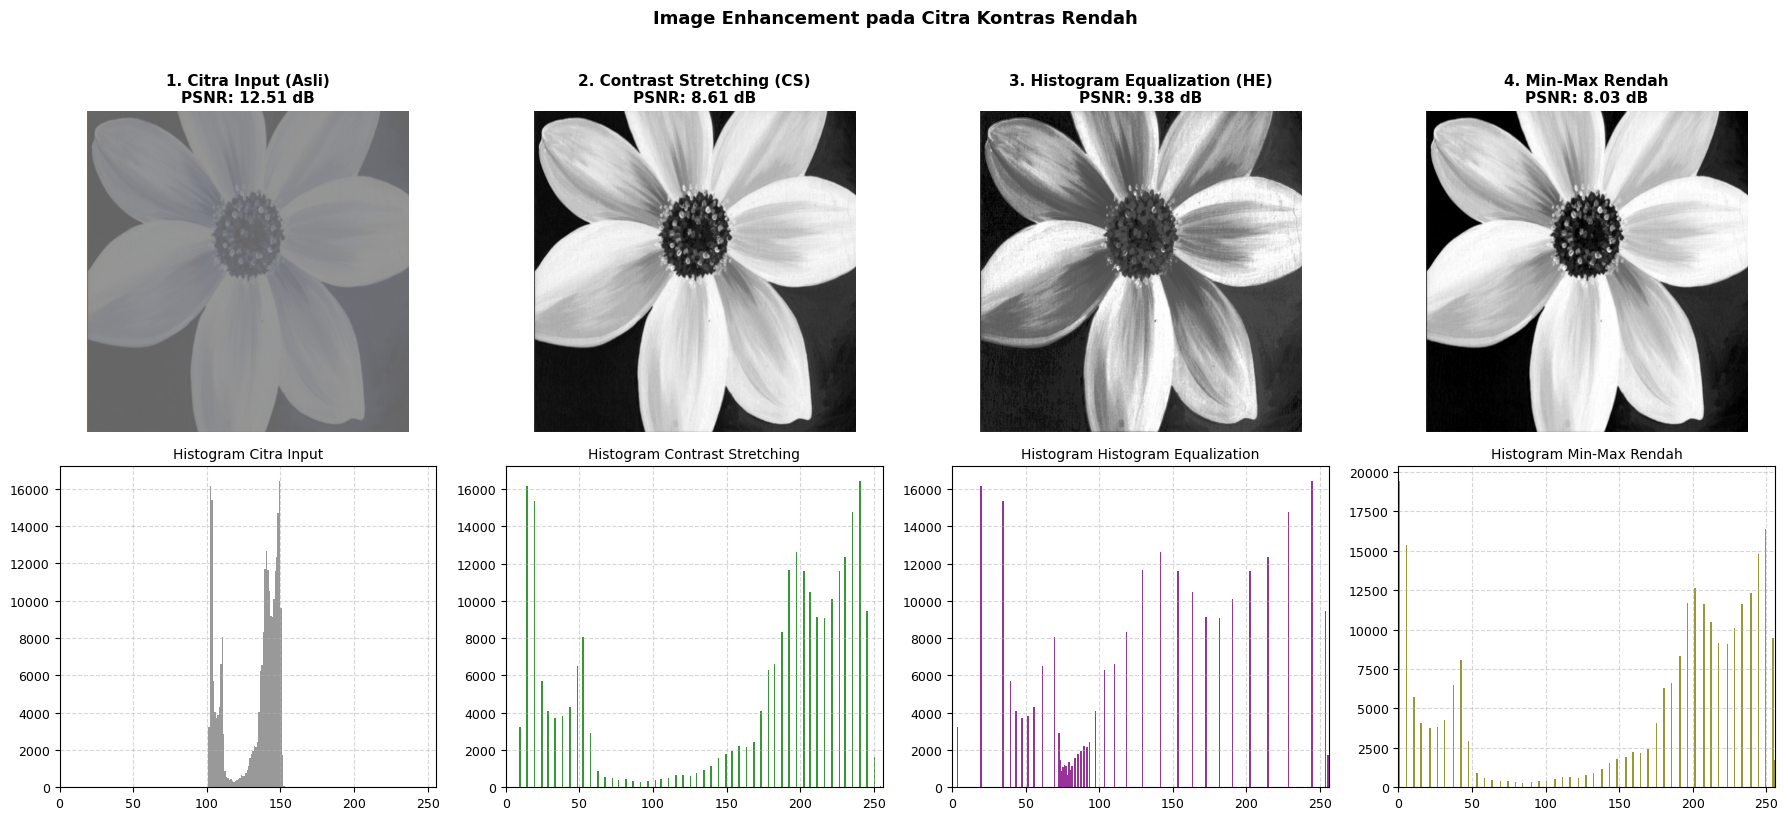

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Low-Contrast Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_raw = cv2.imread(filename)
if img_raw is None:
    raise ValueError("Gagal membaca gambar.")

img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)

img_gray = cv2.resize(img_gray, (512, 512))
img_display = cv2.resize(img_rgb, (512, 512))

if 'img_original' not in locals():
    img_original = img_gray.copy()

# 1. Contrast Stretching (CS)
r_min, r_max = np.min(img_gray), np.max(img_gray)
if r_max - r_min == 0:
    img_cs = img_gray.copy()
else:
    img_cs = np.clip((img_gray - r_min) * (255.0 / (r_max - r_min)), 0, 255).astype(np.uint8)

# 2. Histogram Equalization (HE)
img_he = cv2.equalizeHist(img_gray)

# 3. Min-Max Rendah
p_low, p_high = np.percentile(img_gray, (2, 98))
img_minmax = np.clip((img_gray - p_low) * (255.0 / (p_high - p_low + 1e-5)), 0, 255).astype(np.uint8)

psnr_orig = calculate_psnr(img_original, img_gray)
psnr_cs = calculate_psnr(img_original, img_cs)
psnr_he = calculate_psnr(img_original, img_he)
psnr_minmax = calculate_psnr(img_original, img_minmax)

print(f"PSNR Input: {psnr_orig:.2f} dB | CS: {psnr_cs:.2f} dB | HE: {psnr_he:.2f} dB | MinMax: {psnr_minmax:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_display, img_cs, img_he, img_minmax]
titles = [
    "1. Citra Input (Asli)",
    "2. Contrast Stretching (CS)",
    "3. Histogram Equalization (HE)",
    "4. Min-Max Rendah"
]
colors = [None, 'green', 'purple', 'olive']
psnr_vals = [psnr_orig, psnr_cs, psnr_he, psnr_minmax]

for i in range(4):
    if i == 0:
        axes[0, i].imshow(images[i])
    else:
        axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    hist_data = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY) if i == 0 else images[i]

    axes[1, i].hist(hist_data.ravel(), bins=256, range=[0, 256], color=colors[i] if colors[i] else 'gray', alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Image Enhancement pada Citra Kontras Rendah", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra dengan kontras rendah:

1. Citra Input: PSNR 12,51 dB. Citra memiliki kontras rendah sehingga terlihat kusam dan detail kurang jelas.

2. Contrast Stretching (CS): PSNR 8,61 dB. Kontras citra meningkat sehingga objek dan latar belakang lebih jelas.

3. Histogram Equalization (HE): PSNR 9,38 dB. Distribusi intensitas lebih merata dan visibilitas objek meningkat, tetapi beberapa bagian terlihat terlalu terang.

4. Min-Max Rendah: PSNR 8,03 dB. Kontras meningkat, tetapi hasilnya kurang seimbang sehingga beberapa detail terlihat kurang natural.

Kesimpulan: Contrast Stretching dan Histogram Equalization sama-sama meningkatkan kontras secara visual, sedangkan berdasarkan PSNR, Histogram Equalization lebih tinggi dengan nilai 9,38 dB.


# ***`7. IMAGE ENHANCEMENT PADA HIGH CONTRAST`***

High-Contrast Image:


Saving high_image.png to high_image (1).png
PSNR Input: 8.45 dB | Gamma: 8.49 dB | Log Compression: 7.11 dB | Balanced: 9.77 dB


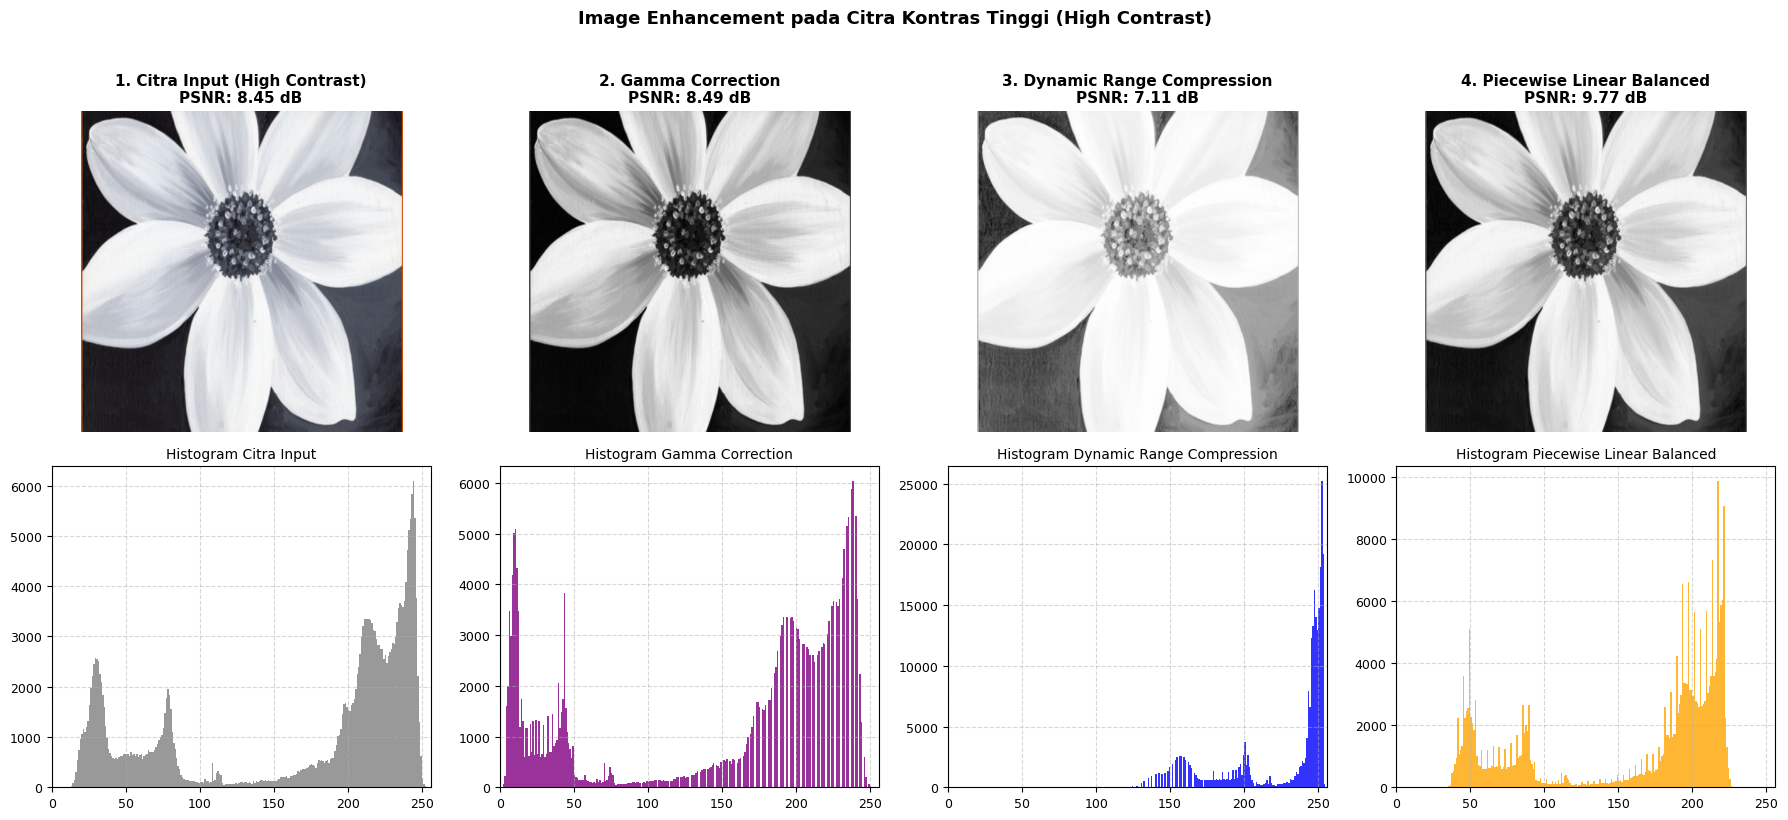

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("High-Contrast Image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_raw = cv2.imread(filename)
if img_raw is None:
    raise ValueError("Gagal membaca gambar.")

img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)

img_gray = cv2.resize(img_gray, (512, 512))
img_display = cv2.resize(img_rgb, (512, 512))

if 'img_original' not in locals():
    img_original = img_gray.copy()

# 1. Gamma Correction (Power-Law)
gamma = 1.5
img_gamma = np.array(255 * (img_gray / 255.0) ** gamma, dtype=np.uint8)

# 2. Dynamic Range Compression
c_param = 255 / np.log(1 + np.max(img_gray))
img_log = np.clip(c_param * np.log(1 + img_gray.astype(np.float32)), 0, 255).astype(np.uint8)

# 3. Piecewise Linear / Brightness & Contrast Adjustment
img_balanced = np.clip(img_gray * 0.8 + 25, 0, 255).astype(np.uint8)

psnr_orig = calculate_psnr(img_original, img_gray)
psnr_gamma = calculate_psnr(img_original, img_gamma)
psnr_log = calculate_psnr(img_original, img_log)
psnr_balanced = calculate_psnr(img_original, img_balanced)

print(f"PSNR Input: {psnr_orig:.2f} dB | Gamma: {psnr_gamma:.2f} dB | Log Compression: {psnr_log:.2f} dB | Balanced: {psnr_balanced:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_display, img_gamma, img_log, img_balanced]
titles = [
    "1. Citra Input (High Contrast)",
    "2. Gamma Correction",
    "3. Dynamic Range Compression",
    "4. Piecewise Linear Balanced"
]
colors = [None, 'purple', 'blue', 'orange']
psnr_vals = [psnr_orig, psnr_gamma, psnr_log, psnr_balanced]

for i in range(4):
    if i == 0:
        axes[0, i].imshow(images[i])
    else:
        axes[0, i].imshow(images[i], cmap='gray')
    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    hist_data = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY) if i == 0 else images[i]

    axes[1, i].hist(hist_data.ravel(), bins=256, range=[0, 256], color=colors[i] if colors[i] else 'gray', alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Image Enhancement pada Citra Kontras Tinggi (High Contrast)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra High Contrast:

1. Citra Input: PSNR 8,45 dB. Citra memiliki kontras yang sangat tinggi dengan perbedaan area gelap dan terang yang cukup tajam.

2. Gamma Correction: PSNR 8,49 dB. Penyesuaian gamma sedikit memperbaiki distribusi intensitas, dengan hasil yang hampir sama dengan citra input.

3. Dynamic Range Compression: PSNR 7,11 dB. Mengurangi rentang intensitas, tetapi pada citra ini hasilnya kurang seimbang dan memiliki PSNR paling rendah.

4. Piecewise Linear Balanced: PSNR 9,77 dB. Menghasilkan PSNR tertinggi dan membuat kontras citra lebih seimbang sehingga detail objek terlihat lebih jelas.

Kesimpulan: Piecewise Linear Balanced memberikan hasil terbaik dengan PSNR 9,77 dB dan tampilan visual yang lebih seimbang.


# ***`8. IMAGE ENHANCEMENT LOW RESOLUTION`***

Low Resolution:


Saving Low_resolution_image.png to Low_resolution_image (1).png
PSNR Low-Res: 27.62 dB | Nearest: 27.62 dB | Bilinear: 29.39 dB | Bicubic: 30.81 dB


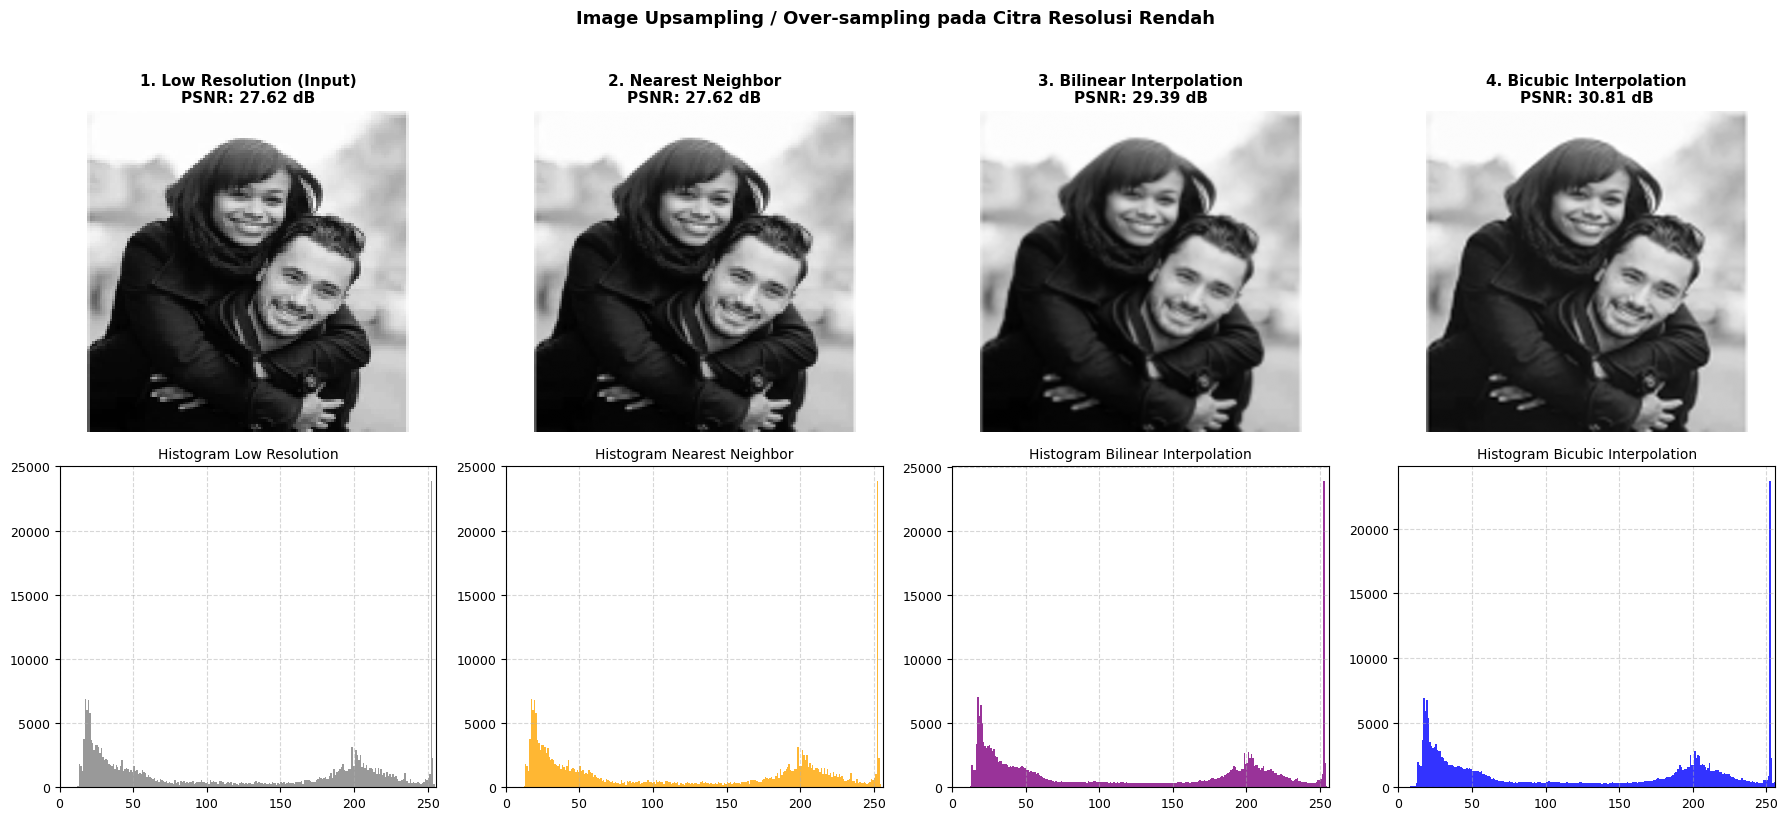

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def calculate_psnr(original, enhanced):
    orig = original.astype(np.float64)
    enh = enhanced.astype(np.float64)
    mse = np.mean((orig - enh) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

print("Low Resolution:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_raw = cv2.imread(filename)
if img_raw is None:
    raise ValueError("Gagal membaca gambar.")

img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
img_gray = cv2.resize(img_gray, (512, 512))
img_display = cv2.resize(img_rgb, (512, 512))

# Simulasi Low Resolution: Downsample
h, w = img_gray.shape
img_low = cv2.resize(img_gray, (w // 4, h // 4), interpolation=cv2.INTER_AREA)

# 1. Nearest Neighbor
img_nearest = cv2.resize(img_low, (w, h), interpolation=cv2.INTER_NEAREST)

# 2. Bilinear Interpolation
img_linear = cv2.resize(img_low, (w, h), interpolation=cv2.INTER_LINEAR)

# 3. Bicubic Interpolation
img_cubic = cv2.resize(img_low, (w, h), interpolation=cv2.INTER_CUBIC)

psnr_low = calculate_psnr(img_gray, cv2.resize(img_low, (w, h), interpolation=cv2.INTER_NEAREST))
psnr_nearest = calculate_psnr(img_gray, img_nearest)
psnr_linear = calculate_psnr(img_gray, img_linear)
psnr_cubic = calculate_psnr(img_gray, img_cubic)

print(f"PSNR Low-Res: {psnr_low:.2f} dB | Nearest: {psnr_nearest:.2f} dB | Bilinear: {psnr_linear:.2f} dB | Bicubic: {psnr_cubic:.2f} dB")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

images = [img_low, img_nearest, img_linear, img_cubic]
titles = [
    "1. Low Resolution (Input)",
    "2. Nearest Neighbor",
    "3. Bilinear Interpolation",
    "4. Bicubic Interpolation"
]
colors = ['gray', 'orange', 'purple', 'blue']
psnr_vals = [psnr_low, psnr_nearest, psnr_linear, psnr_cubic]

for i in range(4):
    if i == 0:
        axes[0, i].imshow(images[i], cmap='gray', interpolation='nearest')
    else:
        axes[0, i].imshow(images[i], cmap='gray')

    axes[0, i].set_title(f"{titles[i]}\nPSNR: {psnr_vals[i]:.2f} dB", fontsize=11, fontweight='bold')
    axes[0, i].axis('off')

    hist_data = cv2.resize(images[i], (w, h), interpolation=cv2.INTER_NEAREST) if i == 0 else images[i]

    axes[1, i].hist(hist_data.ravel(), bins=256, range=[0, 256], color=colors[i], alpha=0.8)
    axes[1, i].set_title(f"Histogram {titles[i].split('.')[1].split('(')[0].strip()}", fontsize=10)
    axes[1, i].set_xlim([0, 256])
    axes[1, i].grid(True, linestyle='--', alpha=0.5)
    axes[1, i].tick_params(axis='both', labelsize=9)

plt.suptitle("Image Upsampling / Over-sampling pada Citra Resolusi Rendah", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan Hasil Eksperimen

Berdasarkan hasil visual dan nilai PSNR pada citra Low Resolution:

1. Low Resolution (Input): PSNR 27,62 dB. Citra memiliki resolusi rendah dan menjadi acuan sebelum dilakukan pembesaran.

2. Nearest Neighbor: PSNR 27,62 dB. Piksel diperbesar dengan mengambil nilai piksel terdekat sehingga hasilnya cenderung pixelated.

3. Bilinear Interpolation: PSNR 29,39 dB. Hasil citra lebih halus karena menggunakan beberapa piksel tetangga dalam proses interpolasi.

4. Bicubic Interpolation: PSNR 30,81 dB. Menghasilkan PSNR tertinggi dan memberikan hasil yang lebih halus serta detail objek lebih terjaga.

Kesimpulan: Bicubic Interpolation memberikan hasil terbaik dengan nilai PSNR 30,81 dB.